<a href="https://colab.research.google.com/github/DengAchiek/Data-science/blob/main/retail_churn_ensemble_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ensemble Models: Random Forests and Boosting Lab

## Retail Customer Churn Model

As a junior data scientist at RetailTech Solutions, a retail analytics firm, you've been assigned to help a major e-commerce client predict customer churn. The client has noticed an increasing trend of customers abandoning their platform, despite competitive pricing and a wide product range.

Your team lead has provided you with historical customer data containing various metrics including usage patterns, customer support interactions, and account details. Your task is to build several ensemble models to predict which customers are at risk of churning, and identify the key factors driving customer departures.

The VP of Customer Experience will use your insights to develop targeted retention strategies, so both prediction accuracy and model interpretability are important. You'll apply the ensemble learning techniques you've learned, specifically Random Forest and Boosting, to address this business challenge.

## Modelling Process for Lab:
- Data Exploration
- Data Setup
- Baseline Model (Random Forest)
- Boosting Models
- Hyperparameter Tuning
- Feature Importance

## Data Overview
Data File: ecommerce_customer_data.csv

This dataset contains 15,000 customer records with 14 features and the churn target variable.

Contains columns:
- account_age_months: Number of months since customer account creation (numeric)
- avg_orders_per_month: Average number of orders placed monthly (numeric)
- avg_order_value: Average dollar amount spent per order (numeric)
- returns_rate: Proportion of items returned from total orders (numeric, 0-1)
- support_tickets_6m: Number of customer support tickets in last 6 months (integer)
- reviews_submitted: Total number of product reviews submitted (integer)
- website_visits_per_month: Average website visits per month (integer)
- cart_abandonment_rate: Proportion of shopping carts abandoned (numeric, 0-1)
- loyalty_member: Whether customer joined loyalty program (binary: 0=No, 1=Yes)
- payment_failures_12m: Number of payment failures in last 12 months (integer)
- device_type: Primary device used for shopping (ordinal: 1=Mobile, 2=Mixed, 3=Desktop)
- discount_usage_rate: Proportion of orders using discount codes (numeric, 0-1)
- days_since_last_active: Number of days since last website activity (integer)
- satisfaction_score: Customer satisfaction rating (ordinal: 1-10)
- churn: Target variable indicating customer has left (binary: 0=Retained, 1=Churned)


## Part 0: Setup - Import Libraries and Load Data

First, let's import all the necessary libraries and load the dataset.

In [ ]:
# CodeGrade step0
# Run this cell without changes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, xgboost
from IPython.display import display as show_table
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.base import clone
from xgboost import XGBClassifier
sns.set_theme(style="darkgrid")
#warnings.filterwarnings('ignore')

# Load the e-commerce customer data
df_ecom = pd.read_csv('/content/ecommerce_customer_data.csv')

In [ ]:
# Check the data
df_ecom.head()

,account_age_months,avg_orders_per_month,avg_order_value,returns_rate,support_tickets_6m,reviews_submitted,website_visits_per_month,cart_abandonment_rate,loyalty_member,payment_failures_12m,device_type,discount_usage_rate,days_since_last_active,satisfaction_score,churn
0,30.0,2.71,10.00,0.184,2,0,14,0.593,0,0,1,0.117,13,7,1
1,22.0,2.93,38.08,0.038,4,5,6,0.652,1,0,2,0.306,1,8,0
2,32.0,3.13,54.45,0.196,3,0,5,0.646,1,2,1,0.000,1,2,1
3,42.0,4.89,80.24,0.095,0,6,14,0.735,0,0,1,0.158,52,6,0
4,21.0,1.51,110.85,0.168,1,1,1,0.418,1,0,2,0.213,112,3,1


## Part 1: Data Exploration

In the first part here you are tasked with performing some basic EDA to investigate your data (features and target).

In [ ]:
# Run this cell without changes
df_ecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   account_age_months        15000 non-null  float64
 1   avg_orders_per_month      15000 non-null  float64
 2   avg_order_value           15000 non-null  float64
 3   returns_rate              15000 non-null  float64
 4   support_tickets_6m        15000 non-null  int64  
 5   reviews_submitted         15000 non-null  int64  
 6   website_visits_per_month  15000 non-null  int64  
 7   cart_abandonment_rate     15000 non-null  float64
 8   loyalty_member            15000 non-null  int64  
 9   payment_failures_12m      15000 non-null  int64  
 10  device_type               15000 non-null  int64  
 11  discount_usage_rate       15000 non-null  float64
 12  days_since_last_active    15000 non-null  int64  
 13  satisfaction_score        15000 non-null  int64  
 14  churn 

Inspect types, missing values, duplicates and summary statistics before fitting. No records are silently removed. Validate that the target is binary and all supplied features are numerical.

In [ ]:
print('Shape:', df_ecom.shape)
print('Missing values:', df_ecom.isna().sum().sum())
print('Duplicate rows:', df_ecom.duplicated().sum())
assert set(df_ecom['churn'].unique()) == {0, 1}
assert df_ecom.select_dtypes(include='number').shape[1] == df_ecom.shape[1]
assert not df_ecom.isna().any().any()
show_table(df_ecom.describe().T)

Shape: (15000, 15)
Missing values: 0
Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
account_age_months,15000.0,24.153267,11.713024,1.0,16.0000,24.000,32.000,71.00
avg_orders_per_month,15000.0,3.050275,1.879592,0.0,1.6300,3.005,4.350,10.00
avg_order_value,15000.0,75.474873,34.023699,10.0,51.1075,75.090,99.000,205.47
returns_rate,15000.0,0.104244,0.073087,0.0,0.0460,0.100,0.155,0.40
support_tickets_6m,15000.0,2.453733,2.388969,0.0,0.0000,2.000,4.000,13.00
reviews_submitted,15000.0,3.258867,2.631460,0.0,1.0000,3.000,5.000,14.00
website_visits_per_month,15000.0,8.339333,5.382724,1.0,4.0000,8.000,12.000,31.00
cart_abandonment_rate,15000.0,0.600470,0.195433,0.0,0.4670,0.603,0.735,1.00
loyalty_member,15000.0,0.401867,0.490292,0.0,0.0000,0.000,1.000,1.00
payment_failures_12m,15000.0,0.969533,0.994252,0.0,0.0000,1.000,2.000,6.00


I will use pandas `value_counts()` to obtain the exact counts and percentages. And the plot shows class balance; a majority-class benchmark helps judge whether model accuracy adds value.

,count,percent
churn,,
0,9736,64.906667
1,5264,35.093333


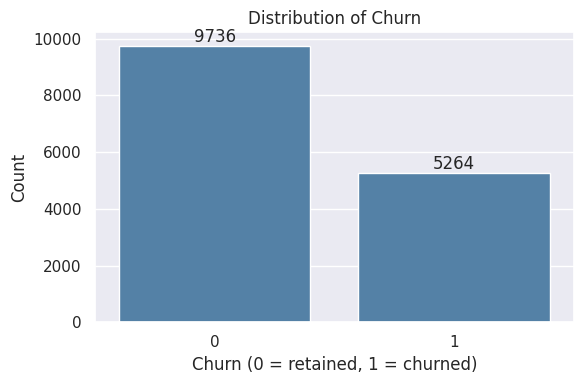

In [ ]:
# CodeGrade step1
# Investigate the class distribution of churn via value_counts and visualization
churn_counts = df_ecom['churn'].value_counts().sort_index()
show_table(pd.DataFrame({'count': churn_counts, 'percent': churn_counts / len(df_ecom) * 100}))
X = churn_counts.index
y = churn_counts.values
plt.figure(figsize=(6,4))
ax = sns.barplot(x=X, y=y, color='steelblue')
ax.bar_label(ax.containers[0], fmt='%d')
plt.xlabel('Churn (0 = retained, 1 = churned)')
plt.ylabel('Count')
plt.title('Distribution of Churn')
plt.tight_layout()
plt.show()

I will create a pandas correlation Series from the churn column of the Pearson correlation matrix. Exclude the target’s self-correlation from the chart. Positive values indicate higher churn association; negative values indicate lower association. These describe linear association, not causation. `device_type` is an encoded nominal category, so its numeric correlation depends on arbitrary codes. This EDA does not drive feature selection; all predictors are retained.

,churn
churn,1.000000
support_tickets_6m,0.453958
returns_rate,0.408676
days_since_last_active,0.128634
payment_failures_12m,0.060467
cart_abandonment_rate,0.047411
discount_usage_rate,0.000945
device_type,-0.002159
reviews_submitted,-0.023658
account_age_months,-0.055466


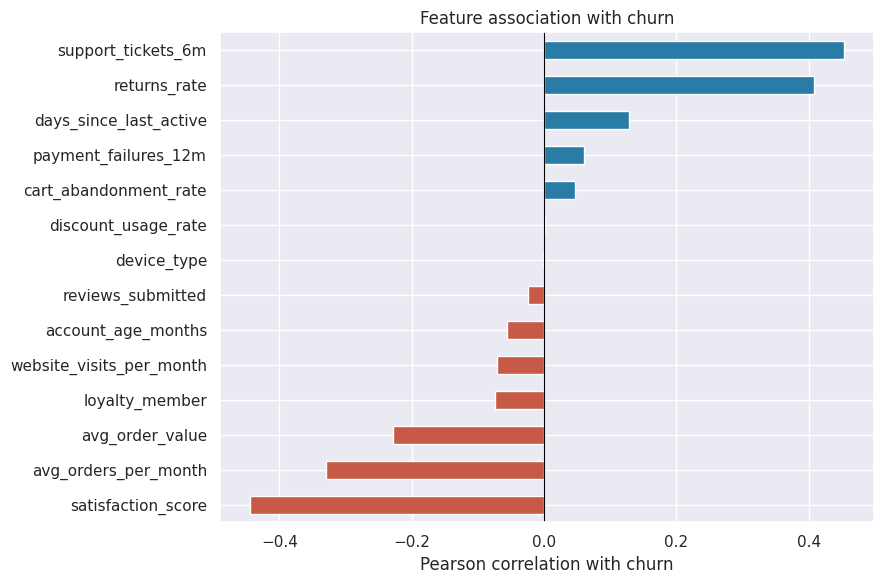

In [ ]:
# CodeGrade step2
# Produce a correlation matrix using pandas to visualize potential important features
# Show correlations with churn (subset the matrix to just churn column
correlations = df_ecom.corr(numeric_only=True)['churn'].sort_values(ascending=False)
show_table(correlations)
feature_correlations = correlations.drop('churn').sort_values()
plt.figure(figsize=(9,6))
feature_correlations.plot.barh(color=['#c65a46' if v < 0 else '#287ca5' for v in feature_correlations])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson correlation with churn')
plt.title('Feature association with churn')
plt.tight_layout()
plt.show()

## Part 2: Data Setup

You need to prepare the data for modeling. The data provided is already processed and cleaned for the sake of this lab (categorical variables encoded). Seperate your data into X features and y target and then perform a train test split.
- Set random_state = 42
- Ensure an 80-20 split (train-test)

In [ ]:
# CodeGrade step3
# Seperate data into X and y - use all features
X = df_ecom.drop(columns='churn')
y = df_ecom['churn']

# Split data using sklearn, follow the standard naming conventions (X_train, X_test etc...)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
cv = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X_train, y_train))

print('Training:', X_train.shape, '| Testing:', X_test.shape)
show_table(pd.DataFrame({'train_fraction': y_train.value_counts(normalize=True), 'test_fraction': y_test.value_counts(normalize=True)}))
majority_accuracy = y_train.value_counts(normalize=True).max()
print(f'Training majority-class accuracy benchmark: {majority_accuracy:.4f}')

Training: (12000, 14) | Testing: (3000, 14)


,train_fraction,test_fraction
churn,,
0,0.649083,0.649
1,0.350917,0.351


Training majority-class accuracy benchmark: 0.6491


## Part 3: Baseline Random Forest Model
You need to instansiate and train (fit) an untuned random forest classifier and evaluate it using cross-validation. Use the default score of accuracy.
- Set random_state = 42 inside the model

In [ ]:
# CodeGrade step4
# Instanstiate model and fit the model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
# Get training score
rf_train_score = rf_model.score(X_train, y_train)
# Cross validation scores (don't average)
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)



In [ ]:
# Run this cell without changes to display results
print(f'Random Forest Training Score: {rf_train_score:.3f}')
print('Fold accuracies:', rf_cv_scores)
print(f'Random Forest CV Score: {rf_cv_scores.mean():.3f} ± {rf_cv_scores.std():.3f}')

Random Forest Training Score: 1.000
Fold accuracies: [0.90875    0.91541667 0.91333333 0.91       0.91666667]
Random Forest CV Score: 0.913 ± 0.003


## Part 4: Boosting Models
In this section you will iterate on your modelling approach to investigate the performance of various untuned boosting models.
- Use random_state = 42 for all models

In [ ]:
# CodeGrade step5
# Instantiate and fit all models
# Adaboost model
ada_model = AdaBoostClassifier(random_state=42)

# Gradient Boosting model
grad_model = GradientBoostingClassifier(random_state=42)

# XBGboost model
xgb_model = XGBClassifier(random_state=42, n_jobs=1)
for model in [ada_model, grad_model, xgb_model]:
    model.fit(X_train, y_train)

# Get training scores
ada_train_score = ada_model.score(X_train, y_train)
grad_train_score = grad_model.score(X_train, y_train)
xgb_train_score = xgb_model.score(X_train, y_train)

# Cross validate all models using accuracy (don't average the scores)
ada_cv_scores = cross_val_score(ada_model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)
grad_cv_scores = cross_val_score(grad_model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)

In [ ]:
# Run this cell without changes to dsiplay results
print(f"Training and Cross Validation Performance Comparison of Boosted Models")
print(f"Adaptive Boosting: Train - {ada_train_score:.3f}, CV - {ada_cv_scores.mean():.3f}")
print(f"Gradient Boosting: Train - {grad_train_score:.3f}, CV - {grad_cv_scores.mean():.3f}")
print(f"Extreme Gradient Boosting: Train - {xgb_train_score:.3f}, CV - {xgb_cv_scores.mean():.3f}")

Training and Cross Validation Performance Comparison of Boosted Models
Adaptive Boosting: Train - 0.921, CV - 0.914
Gradient Boosting: Train - 0.939, CV - 0.920
Extreme Gradient Boosting: Train - 0.999, CV - 0.923


**Additional visuals for comparison performance**




Compare mean CV accuracy, fold standard deviation and the training CV gap. A large gap suggests overfitting. Select the best baseline using CV accuracy only; small differences should not be treated as conclusive proof of superiority.

,training_accuracy,cv_accuracy,cv_std,train_cv_gap
model,,,,
XGBoost,0.999000,0.923167,0.002846,0.075833
Gradient Boosting,0.939083,0.920500,0.004094,0.018583
AdaBoost,0.921333,0.914083,0.002781,0.007250
Random Forest,1.000000,0.912833,0.003044,0.087167


Best baseline by mean CV accuracy: XGBoost


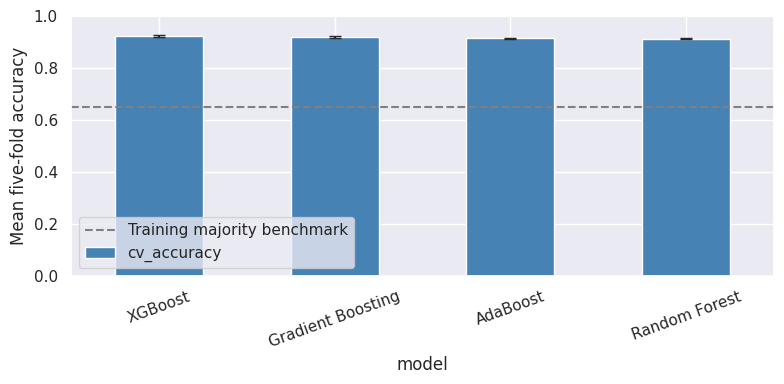

In [ ]:
models = {'Random Forest': rf_model, 'AdaBoost': ada_model, 'Gradient Boosting': grad_model, 'XGBoost': xgb_model}
fold_scores = {'Random Forest': rf_cv_scores, 'AdaBoost': ada_cv_scores, 'Gradient Boosting': grad_cv_scores, 'XGBoost': xgb_cv_scores}
comparison = pd.DataFrame([{'model': name, 'training_accuracy': model.score(X_train, y_train), 'cv_accuracy': fold_scores[name].mean(), 'cv_std': fold_scores[name].std()} for name, model in models.items()]).set_index('model')
comparison['train_cv_gap'] = comparison.training_accuracy - comparison.cv_accuracy
comparison = comparison.sort_values('cv_accuracy', ascending=False)
show_table(comparison)
best_baseline_name = comparison.index[0]
print('Best baseline by mean CV accuracy:', best_baseline_name)
comparison['cv_accuracy'].plot.bar(yerr=comparison['cv_std'], capsize=4, figsize=(8,4), color='steelblue')
plt.axhline(majority_accuracy, linestyle='--', color='gray', label='Training majority benchmark')
plt.ylabel('Mean five-fold accuracy')
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

## Part 5: Hyperparameter Tuning

Based on the results above you want to select the model that has the most room for improvement (is overfitting with highest train score) and attempt to optimize the model via a targeted Grid Search. Utilize the provided hyperparameters and values for your grid.
- 'learning_rate': [0.05, 0.1]
- 'n_estimators': [200, 300]
- 'max_depth': [3, 5]
- 'min_child_weight': [1, 5]
- 'scale_pos_weight': [1, 3]

NOTE: You should expect this grid search to take a minute or two to run

In [ ]:
# CodeGrade step6
# Assign the model object
gs_model = XGBClassifier(random_state=42, n_jobs=1)

# Create Param Grid
param_grid = {'learning_rate': [0.05, 0.1], 'n_estimators': [200, 300],
              'max_depth': [3, 5], 'min_child_weight': [1, 5],
              'scale_pos_weight': [1, 3]}

# Instantiate GridSearchCV object
grid_search = GridSearchCV(gs_model, param_grid, scoring='accuracy',
                           cv=cv, n_jobs=1, refit=True, error_score='raise')


# Perform the grid search (fit)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=[(array([    0,     1,     3, ..., 11996, 11998, 11999]),
                  array([    2,     5,    13, ..., 11986, 11994, 11997])),
                 (array([    0,     1,     2, ..., 11997, 11998, 11999]),
                  array([    6,     7,    18, ..., 11988, 11995, 11996])),
                 (array([    0,     1,     2, ..., 11997, 11998, 11999]),
                  array([    9,    10,    11, ..., 11982, 11989, 11990])),
                 (array([    2,     5,     6, ..., 11997, 11998, 11999]),
                  array([    0,     1,     3, ..., 11991, 11992, 11993])),
                 (array([    0,     1,     2, ..., 11995, 1...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=1, num_parallel_tree=None, ...),
             n_jobs=1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'min_child_weight': [1, 5], 'n_estimators': [200, 300],
                         'scale_pos_weight': [1, 3]},
             scoring='accuracy')

In [ ]:
# Run this cell without changes to display results
print("Best Model Results from Grid Search")
print(f"CV Score: {grid_search.best_score_:.3f}")
print(f"Best Hyperparameters: {grid_search.best_params_}")

Best Model Results from Grid Search
CV Score: 0.928
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 300, 'scale_pos_weight': 1}


In [ ]:
show_table(pd.DataFrame(grid_search.cv_results_)
.sort_values('rank_test_score')[['params','mean_test_score','std_test_score','rank_test_score']].head())

,params,mean_test_score,std_test_score,rank_test_score
22,"{'learning_rate': 0.1, 'max_depth': 3, 'min_ch...",0.928083,0.002759,1
18,"{'learning_rate': 0.1, 'max_depth': 3, 'min_ch...",0.927000,0.003009,2
16,"{'learning_rate': 0.1, 'max_depth': 3, 'min_ch...",0.926583,0.002680,3
20,"{'learning_rate': 0.1, 'max_depth': 3, 'min_ch...",0.926500,0.002858,4
28,"{'learning_rate': 0.1, 'max_depth': 5, 'min_ch...",0.925333,0.002519,5


**Tune the best baseline, if different**

In [ ]:
# Reuse the existing XGBoost grid search if XGBoost is the best baseline model.
if best_baseline_name == 'XGBoost':
    best_baseline_search = grid_search
else:
   # Define the hyperparameter combinations to test for each other baseline model.
    grids = {
        'Random Forest': {'n_estimators': [100, 200], 'max_depth': [None, 10], 'min_samples_leaf': [1, 3]},
        'AdaBoost': {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1, 1.0]},
        'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}
    }
    # Search for the best hyperparameters using cross-validation accuracy.
    best_baseline_search = GridSearchCV(clone(models[best_baseline_name]), grids[best_baseline_name], cv=cv, scoring='accuracy', n_jobs=1, refit=True, error_score='raise')
    best_baseline_search.fit(X_train, y_train)
print('Tuned baseline:', best_baseline_name)
print('Parameters:', best_baseline_search.best_params_)
print(f'CV accuracy: {best_baseline_search.best_score_:.4f}')
candidate_scores = comparison['cv_accuracy'].to_dict()
candidate_models = models.copy()
candidate_scores['Tuned XGBoost'] = grid_search.best_score_
candidate_models['Tuned XGBoost'] = grid_search.best_estimator_
candidate_scores['Tuned ' + best_baseline_name] = best_baseline_search.best_score_
candidate_models['Tuned ' + best_baseline_name] = best_baseline_search.best_estimator_
selected_name = max(candidate_scores, key=candidate_scores.get)
selected_model = candidate_models[selected_name]
print('Development candidate selected by CV:', selected_name)

Tuned baseline: XGBoost
Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 300, 'scale_pos_weight': 1}
CV accuracy: 0.9281
Development candidate selected by CV: Tuned XGBoost


## Part 6: Final Model Analysis

For the sake of timing we will stop at one grid search. In practice (especially with advanced boosting models) multiple searchs are probably warranted, this grid search only touches a few of the most important hyperparameters involved. Treat the best estimator from the grid search as your final model.

In [ ]:
# CodeGrade step7
# Extract final model
final_model = grid_search.best_estimator_

# Final Model training accurary
final_score_train = final_model.score(X_train, y_train)

# Final model testing accuracy
final_score_test = final_model.score(X_test, y_test)

# Produce classificaiton report
y_pred_test = final_model.predict(X_test)
cr = classification_report(y_test, y_pred_test)

# Produce confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

Final Model Evaluation
Accuracy on the Training Data: 0.956
Accuracy on the Testing Data: 0.929
Classification Report
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1947
           1       0.90      0.90      0.90      1053

    accuracy                           0.93      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.93      0.93      0.93      3000

Confusion Matrix


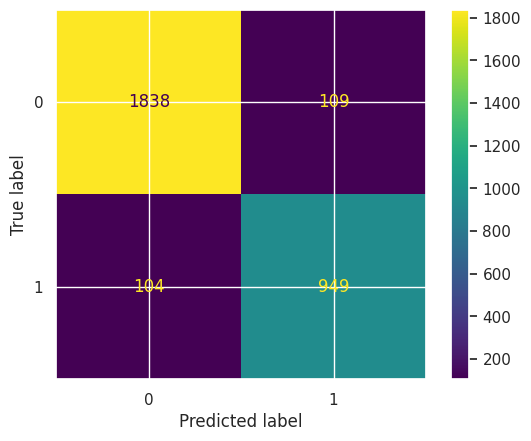

In [ ]:
# Run this cell without changes to display results
print(f"Final Model Evaluation")
print(f"Accuracy on the Training Data: {final_score_train:.3f}")
print(f"Accuracy on the Testing Data: {final_score_test:.3f}")
print(f"Classification Report")
print(cr)
print(f"Confusion Matrix")
display = ConfusionMatrixDisplay(cm)
display.plot();

Your boss specifically wanted a model with high accuracy and interpretability which you have achieved! However, based on the results above and what you know about churn and business context, what might be a good alternative metric to try and optimize for?

Select from one of the options below:
- recall
- f1_score
- precision
- roc_auc

In [ ]:
# CodeGrade step8
# Assign name of metric as string
alternative_metric = 'recall'
print('Alternative optimization metric:', alternative_metric)

Alternative optimization metric: recall


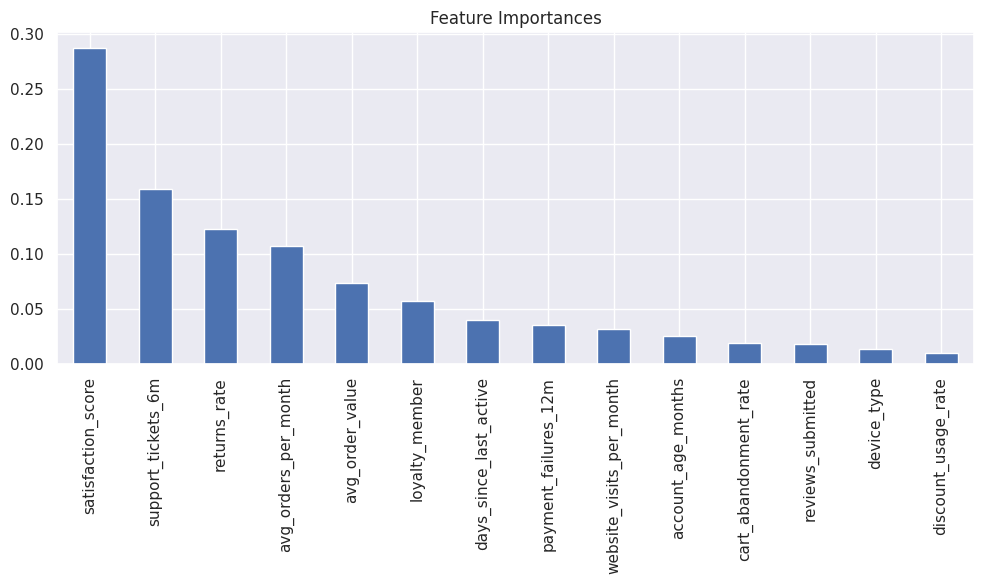

In [ ]:
# CodeGrade step9
# Extract feature importance from final model
feature_importance = final_model.feature_importances_

importances = pd.Series(feature_importance, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

### Findings from the above
The data contains **15,000 customers: 5,264 churners (35.09%) and 9,736 retained customers**. The split produces 12,000 training and 3,000 test rows. There are no missing values or duplicate rows.

**XGBoost wins the baseline CV comparison**, so the required XGBoost grid also tunes the best baseline. The winning parameters are learning_rate=0.1, max_depth=3, min_child_weight=5, n_estimators=300 and scale_pos_weight=1. Tuned XGBoost is also the development candidate selected by CV.

The final model achieves **92.81% CV accuracy, 95.59% training accuracy and 92.90% test accuracy**. Churn precision is **89.70%**, recall **90.12%** and F1 **89.91%**. It identifies 949 churners, misses 104, correctly identifies 1,838 retained customers and raises 109 false churn alerts. The remaining training–test gap indicates some overfitting, although the holdout and CV scores are close.

The top three model predictors are **satisfaction_score, support_tickets_6m and returns_rate**. Investigating customer satisfaction, service issues and returns could inform retention hypotheses, but feature importance does not prove that changing these factors will prevent churn.

**Limitations:** A single random holdout does not establish performance across time or populations. Reusing CV folds for selection can make the winning CV score optimistic; fold standard deviations are not confidence intervals. Before deployment, verify that features precede churn, assess temporal generalization, review nominal category encoding and choose retention thresholds using validation data and intervention costs. Test results were not used to select models or tune parameters.


## Interpretation of the executed results
Results are summarized below after execution. No model is assumed to be best before cross-validation. Test results are descriptive final checks and are not used to choose parameters.

## Rubric coverage
| Criterion | Evidence |
|---|---|
| Data exploration | Cells 2–4: quality checks, exact churn counts, chart and pandas correlation Series |
| Data setup | Cell 5: X/y and stratified 80/20 split |
| Baseline Random Forest | Cell 6: fit, training score and five CV accuracy scores |
| Boosting models | Cells 7–8: all three classifiers and identical evaluation |
| Grid search | Cell 9: required XGBoost grid; Cell 10: best-baseline tuning |
| Final analysis | Cells 11–13: holdout report, confusion matrix, recall rationale and importance |

## Method references
- [Scikit-learn: cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)
- [Scikit-learn: GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
- [XGBoost: scikit-learn estimator interface](https://xgboost.readthedocs.io/en/stable/python/sklearn_estimator.html)